In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
##DATA INSPECTION
# load dataset
telco_df = telco_df = pd.read_csv("Telco-Customer-Churn.csv")

# display first 10 rows
telco_df.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,Yes,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
# names of the columns
telco_df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [5]:
# data types of each column
telco_df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
##DATA PREPROCESSING
# convert TotalCharges to numeric data type
telco_df["TotalCharges"] = pd.to_numeric(telco_df["TotalCharges"], errors="coerce")
telco_df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [7]:
# remove customerID column
telco_df = telco_df.drop("customerID", axis=1)

In [8]:
# convert the numeric to binary
telco_df["Churn"] = telco_df["Churn"].replace({"Yes": 1, "No": 0})

In [9]:
# convert all the categorical variables into dummy variables
telecom_cust_dummies = pd.get_dummies(telco_df, drop_first=True)
print(telecom_cust_dummies.columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_1'],
      dtype='str')


In [10]:
##DATA VISUALISATION
# calculate the correlation matrix
target = telecom_cust_dummies["Churn_1"]
churn_corr = telecom_cust_dummies.corrwith(target).sort_values(ascending=False)

print(churn_corr)

Churn_1                                  1.000000
InternetService_Fiber optic              0.308020
PaymentMethod_Electronic check           0.301919
MonthlyCharges                           0.193356
PaperlessBilling_Yes                     0.191825
SeniorCitizen                            0.150889
StreamingTV_Yes                          0.063228
StreamingMovies_Yes                      0.061382
MultipleLines_Yes                        0.040102
PhoneService_Yes                         0.011942
gender_Male                             -0.008612
MultipleLines_No phone service          -0.011942
DeviceProtection_Yes                    -0.066160
OnlineBackup_Yes                        -0.082255
PaymentMethod_Mailed check              -0.091683
PaymentMethod_Credit card (automatic)   -0.134302
Partner_Yes                             -0.150448
Dependents_Yes                          -0.164221
TechSupport_Yes                         -0.164674
OnlineSecurity_Yes                      -0.171226


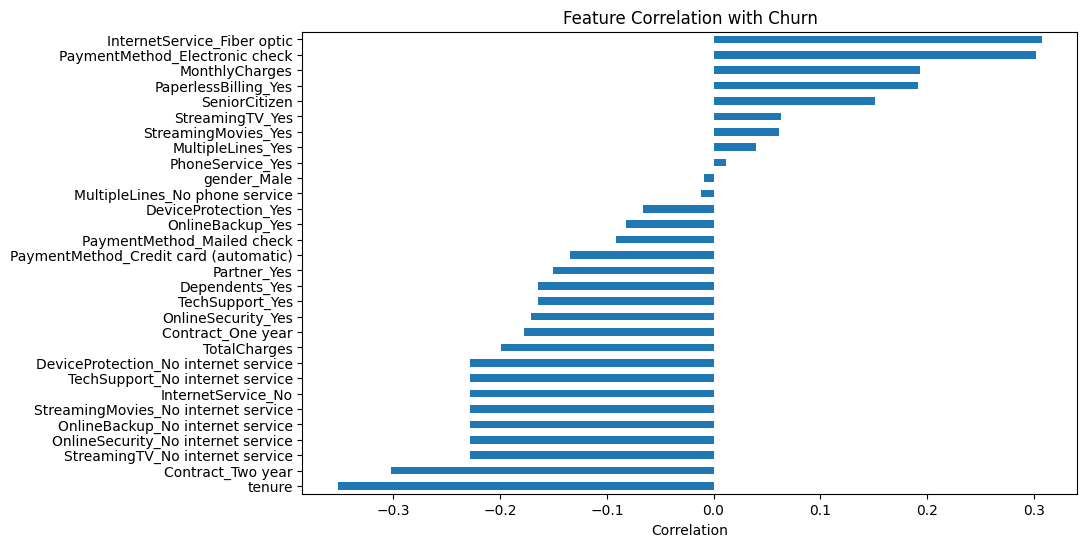

In [11]:
# Remove Churn  (correlation with itself = 1)
churn_corr = churn_corr.drop("Churn_1")

plt.figure(figsize=(10, 6))
churn_corr.sort_values().plot(kind="barh")

plt.title("Feature Correlation with Churn")
plt.xlabel("Correlation")
plt.show()

Feature Correlation with Customer Churn

The correlation plot shows the relationship between each feature and the target variable Churn.
Features with positive correlation (e.g. Internet Service Fiber optic, Monthly Charges) increase the likelihood of churn.
Features with negative correlation (e.g. tenure, Contract type) reduce the likelihood of churn.
The strongest positive drivers of churn include customers using fiber optic internet and electronic check payments.
The strongest negative driver is tenure, meaning long-term customers are less likely to leave.

Overall, the plot highlights that contract type, tenure, and service charges are the most important factors influencing customer churn.

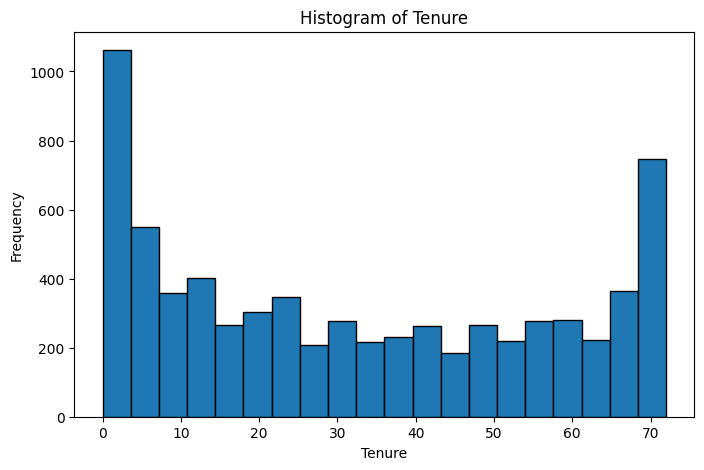

In [12]:
# histogram for tenure
plt.figure(figsize=(8, 5))
plt.hist(telecom_cust_dummies["tenure"], bins=20, edgecolor="black")
plt.title("Histogram of Tenure")
plt.xlabel("Tenure")
plt.ylabel("Frequency")
plt.show()

#Interpretation of Tenure Histogram

The histogram shows the distribution of customer tenure.
The highest frequency occurs at tenure 0, indicating a large number of customers who are very new or have just joined. This suggests a high potential early churn.
There is a second noticeable peak at around 70 months, showing a group of long-term customers who have stayed with the company for a long period.
Between these two peaks, the frequency is lower across the middle tenure range, meaning fewer customers remain in the mid duration stage compared to those who are either new or long-term.

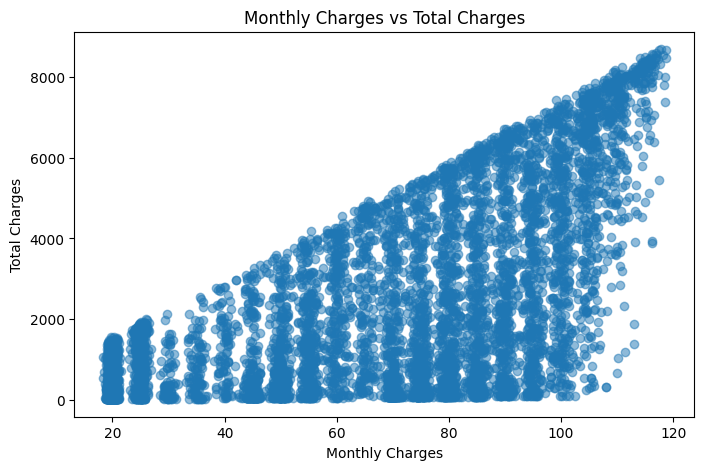

In [13]:
# create scatter plot of monthlycharges and totalcharges
plt.figure(figsize=(8, 5))
plt.scatter(
    telecom_cust_dummies["MonthlyCharges"],
    telecom_cust_dummies["TotalCharges"],
    alpha=0.5,
)
plt.title("Monthly Charges vs Total Charges")
plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")

plt.show()

There is a positive correlation. As the monthly charges the total charges paid increase

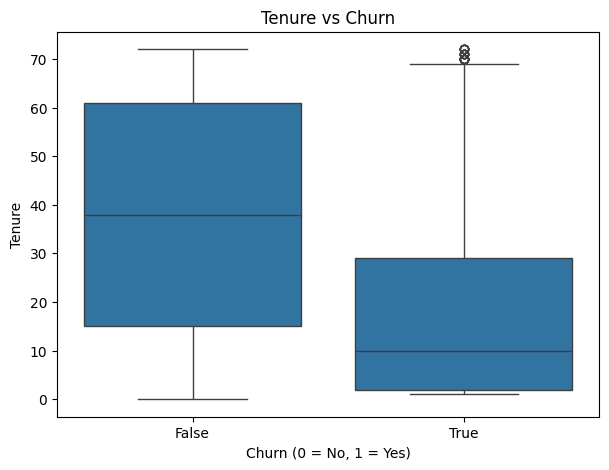

In [14]:
# a box plot to compare tenure for churned and non-churned customers
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.boxplot(x="Churn_1", y="tenure", data=telecom_cust_dummies)

plt.title("Tenure vs Churn")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Tenure")

plt.show()

Churned customers have a lower medain, around 8. Most churning occuts in the early stages of the lifecyle.

In [23]:
telecom_cust_dummies = telecom_cust_dummies.dropna()

In [ ]:
# scale and split the data
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

X = telecom_cust_dummies.drop("Churn_1", axis=1)
y = telecom_cust_dummies["Churn_1"]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42
)

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [ ]:
# make predictions
y_pred = log_model.predict(X_test)
y_pred

array([False, False,  True, ..., False, False, False], shape=(1758,))

In [ ]:
# accuracy score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7912400455062572


A logistic regression model was trained on the processed and scaled training data to predict customer churn. The model was then evaluated on the test dataset (25% of the data).

The model achieved an accuracy score of 79.1%, meaning that approximately 79 out of every 100 predictions made by the model were correct.

This indicates that the model has a good predictive performance, showing that it is able to effectively identify patterns in the data that distinguish between customers who churn and those who do not.

In [ ]:
# random forest classifier
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=2000,
    oob_score=True,
    max_features="sqrt",
    max_leaf_nodes=50,
    bootstrap=True,  # enable bootstrapping
    random_state=42,
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",2000
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",50
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [ ]:
# make predictions
y_pred_rf = rf_model.predict(X_test)

In [ ]:
# evaluate accuracy
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", accuracy_rf)

Random Forest Accuracy: 0.7935153583617748


In [ ]:
# OOB check
print("OOB Score:", rf_model.oob_score_)

OOB Score: 0.807356844899507


Random Forest Model Evaluation
A Random Forest classifier was trained using 2000 decision trees, with out-of-bag (OOB) estimation enabled, max_features set to 'sqrt', max_leaf_nodes set to 50, and bootstrap sampling activated.

The model achieved a test accuracy of 79.35%, indicating that the model correctly predicted customer churn in approximately 79 out of 100 cases.

The **OOB score of 80.73%provides an internal validation estimate of model performance. This score is slightly higher than the test accuracy, suggesting that the model generalises well to unseen data and is not significantly overfitting.

In [ ]:
# confusion matrix for logistic regression and random forest
from sklearn.metrics import confusion_matrix

# Logistic Regression
cm_log = confusion_matrix(y_test, y_pred)
print("Logistic Regression Confusion Matrix: ", cm_log)

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Random Forest Confusion Matrix: ", cm_rf)

Logistic Regression Confusion Matrix:  [[1154  146]
 [ 221  237]]
Random Forest Confusion Matrix:  [[1187  113]
 [ 250  208]]


In [ ]:
from sklearn.metrics import precision_score, recall_score

# Logistic Regression
precision_log = precision_score(y_test, y_pred)
recall_log = recall_score(y_test, y_pred)

# Random Forest
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)

print("Logistic Regression - Precision:", precision_log)
print("Logistic Regression - Recall:", recall_log)

print("\nRandom Forest - Precision:", precision_rf)
print("Random Forest - Recall:", recall_rf)

Logistic Regression - Precision: 0.618798955613577
Logistic Regression - Recall: 0.517467248908297

Random Forest - Precision: 0.6479750778816199
Random Forest - Recall: 0.45414847161572053


: 

Model Comparison and Conclusion
Both models were evaluated using confusion matrix, precision, and recall.

Logistic Regression achieved a recall of 0.517, which means it is better at correctly identifying customers who churn. Random Forest had a higher precision 0.648 but a lower recall 0.454, meaning it misses more actual churners.

Since churn prediction prioritises identifying customers who are likely to leave,recall is more important than precision.

Therefore, the Logistic Regression model is more suitable for this task as it identifies more churned customers, even though Random Forest is slightly more precise.